# Tech Challenge 1 — Etapa 2: Modelagem com Redes Neurais

**Previsão de Churn em Telecomunicações — MLP (PyTorch) vs. Baselines**

Este notebook cobre a Etapa 2 do projeto:
- Construção e treinamento de uma MLP em PyTorch (com early stopping e mini-batching).
- Adição de um baseline de árvore (Random Forest), complementando os
  baselines lineares da Etapa 1.
- Comparação de todos os modelos (MLP, Regressão Logística, Random Forest,
  Dummy) usando ≥ 4 métricas técnicas.
- Análise de trade-off de custo de negócio (falso positivo vs. falso negativo).
- Registro de todos os experimentos no MLflow.

> Pré-requisito: este notebook assume que `data/raw/telco_customer_churn.csv`
> já existe (gerado/baixado na Etapa 1).


## 1. Setup e imports

In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from churn_prediction.business_cost import compute_business_cost, cost_summary_table
from churn_prediction.config import (
    MLFLOW_EXPERIMENT_NAME,
    MLFLOW_TRACKING_URI,
    SEED,
    set_global_seed,
)
from churn_prediction.data import (
    get_feature_groups,
    load_raw_dataset,
    split_features_target,
    train_test_split_stratified,
)
from churn_prediction.mlp_model import ChurnMLP, predict_proba, train_mlp

set_global_seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print(f"Seed fixada em: {SEED}")
print(f"PyTorch versão: {torch.__version__} | CUDA disponível: {torch.cuda.is_available()}")


Seed fixada em: 42
PyTorch versão: 2.4.1+cu121 | CUDA disponível: False


## 2. Carga dos dados e splits

Reaproveitamos a lógica de carga/tratamento de qualidade da Etapa 1, agora
centralizada em `churn_prediction.data` para evitar duplicação de código.

Criamos **três partições**:
- **Treino** (usado para treinar os modelos e a validação cruzada dos baselines).
- **Validação** (apenas para a MLP — usada pelo early stopping, nunca pelos baselines sklearn).
- **Teste/holdout** (não tocado até a comparação final — idêntico ao holdout da Etapa 1).


In [2]:
df = load_raw_dataset()
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)

# Split adicional, só para a MLP: separa um conjunto de validação do treino,
# usado exclusivamente para decidir quando parar (early stopping).
X_tr, X_val, y_tr, y_val = train_test_split_stratified(X_train, y_train, test_size=0.2)

print(f"Treino (MLP):    {X_tr.shape[0]} amostras")
print(f"Validação (MLP): {X_val.shape[0]} amostras")
print(f"Treino completo (baselines/CV): {X_train.shape[0]} amostras")
print(f"Teste (holdout final):          {X_test.shape[0]} amostras")
print()
print(f"Taxa de churn -> treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

numeric_features, categorical_features = get_feature_groups(X)


Treino (MLP):    4507 amostras
Validação (MLP): 1127 amostras
Treino completo (baselines/CV): 5634 amostras
Teste (holdout final):          1409 amostras

Taxa de churn -> treino: 0.265 | teste: 0.265


## 3. Pipeline de pré-processamento

Mesmo `ColumnTransformer` da Etapa 1 (escala para numéricas, one-hot para
categóricas). Para a MLP, ajustamos o pré-processador apenas no split de
treino (`X_tr`) e aplicamos a mesma transformação em validação e teste —
evitando vazamento de dados (data leakage).


In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ]
)

# Ajustado apenas nos dados de treino da MLP (X_tr), reaproveitado em val/teste.
X_tr_proc = preprocessor.fit_transform(X_tr)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Shape pós pré-processamento: {X_tr_proc.shape[1]} features (após one-hot)")


Shape pós pré-processamento: 40 features (após one-hot)


## 4. Construção e treinamento da MLP (PyTorch)

### Arquitetura
- 2 camadas ocultas (64 → 32 neurônios), ativação **ReLU**.
- **Dropout (0.3)** após cada camada oculta, para regularização — dado o
  volume moderado de dados (7k registros), overfitting é um risco real.
- 1 neurônio de saída (logit), com **`BCEWithLogitsLoss`** como função de
  perda — combina sigmoid + binary cross-entropy de forma numericamente
  estável, sem precisar aplicar sigmoid manualmente antes da loss.

### Tratamento do desbalanceamento de classes
Usamos o parâmetro `pos_weight` da `BCEWithLogitsLoss`, calculado como a
razão entre classes negativas e positivas no treino — efeito equivalente ao
`class_weight="balanced"` usado nos baselines do Scikit-Learn.

### Treinamento
- **Mini-batching**: `batch_size=64`.
- **Early stopping**: monitora a perda de validação, com paciência de 10
  épocas sem melhora; ao final, os pesos do melhor checkpoint são restaurados.
- Otimizador **Adam**, com weight decay (regularização L2).


In [4]:
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"pos_weight calculado (proporção neg/pos no treino): {pos_weight:.3f}")

mlp_model = ChurnMLP(n_features=X_tr_proc.shape[1], hidden_sizes=(64, 32), dropout=0.3)
print(mlp_model)


pos_weight calculado (proporção neg/pos no treino): 2.768
ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [5]:
train_result = train_mlp(
    mlp_model,
    X_tr_proc, y_tr.to_numpy(),
    X_val_proc, y_val.to_numpy(),
    max_epochs=200,
    batch_size=64,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=10,
    pos_weight=pos_weight,
    seed=SEED,
    verbose=True,
)

print()
print(f"Treinamento concluído em {train_result['n_epochs_trained']} épocas")
print(f"Melhor perda de validação: {train_result['best_val_loss']:.4f}")



Treinamento concluído em 39 épocas
Melhor perda de validação: 0.7118


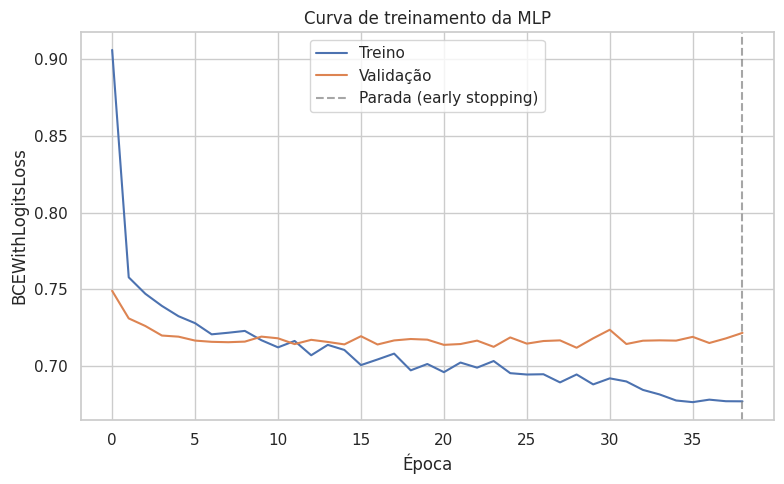

In [6]:
history = train_result["history"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["train_loss"], label="Treino")
ax.plot(history["val_loss"], label="Validação")
ax.axvline(train_result["n_epochs_trained"] - 1, color="gray", linestyle="--", alpha=0.7, label="Parada (early stopping)")
ax.set_xlabel("Época")
ax.set_ylabel("BCEWithLogitsLoss")
ax.set_title("Curva de treinamento da MLP")
ax.legend()
plt.tight_layout()
plt.show()


**Leitura esperada do gráfico:** a perda de treino deve cair de forma
consistente, enquanto a perda de validação estabiliza e eventualmente
começa a subir levemente — é exatamente esse ponto de inflexão que o early
stopping detecta, evitando overfitting ao continuar treinando além do
necessário.


## 5. Baselines: Dummy, Regressão Logística e Random Forest (CV estratificada)

A Etapa 1 já cobriu o baseline `DummyClassifier` e a Regressão Logística.
Nesta etapa, adicionamos um **baseline de árvore (Random Forest)**, conforme
exigido ("comparar MLP vs. baselines, lineares **+ árvores**").

Todos os baselines são reavaliados aqui sobre o mesmo split de treino
(`X_train`/`y_train`), com a mesma validação cruzada estratificada (k=5) da
Etapa 1, para garantir comparabilidade direta com a MLP.


In [7]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate_cv(pipeline, X, y, cv):
    """Avalia um pipeline via CV estratificada, retornando métricas médias."""
    metrics = {"roc_auc": [], "pr_auc": [], "f1": [], "precision": [], "recall": [], "accuracy": []}

    for train_idx, val_idx in cv.split(X, y):
        X_tr_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr_cv, y_tr_cv)
        y_pred = pipeline.predict(X_val_cv)
        y_proba = pipeline.predict_proba(X_val_cv)[:, 1]

        metrics["roc_auc"].append(roc_auc_score(y_val_cv, y_proba))
        metrics["pr_auc"].append(average_precision_score(y_val_cv, y_proba))
        metrics["f1"].append(f1_score(y_val_cv, y_pred))
        metrics["precision"].append(precision_score(y_val_cv, y_pred, zero_division=0))
        metrics["recall"].append(recall_score(y_val_cv, y_pred))
        metrics["accuracy"].append(accuracy_score(y_val_cv, y_pred))

    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}


In [8]:
dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="stratified", random_state=SEED)),
])
dummy_metrics = evaluate_cv(dummy_pipeline, X_train, y_train, cv)

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")),
])
logreg_metrics = evaluate_cv(logreg_pipeline, X_train, y_train, cv)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced", random_state=SEED, n_jobs=-1
    )),
])
rf_metrics = evaluate_cv(rf_pipeline, X_train, y_train, cv)

for name, metrics in [("DummyClassifier", dummy_metrics), ("Regressão Logística", logreg_metrics), ("Random Forest", rf_metrics)]:
    print(f"\n{name} — métricas médias (CV 5-fold estratificada):")
    for metric, (mean, std) in metrics.items():
        print(f"  {metric:10s}: {mean:.4f} +/- {std:.4f}")



DummyClassifier — métricas médias (CV 5-fold estratificada):
  roc_auc   : 0.5065 +/- 0.0171
  pr_auc    : 0.2686 +/- 0.0071
  f1        : 0.2762 +/- 0.0249
  precision : 0.2748 +/- 0.0248
  recall    : 0.2776 +/- 0.0250
  accuracy  : 0.6139 +/- 0.0133

Regressão Logística — métricas médias (CV 5-fold estratificada):
  roc_auc   : 0.8460 +/- 0.0124
  pr_auc    : 0.6600 +/- 0.0195
  f1        : 0.6293 +/- 0.0223
  precision : 0.5178 +/- 0.0186
  recall    : 0.8027 +/- 0.0360
  accuracy  : 0.7492 +/- 0.0150

Random Forest — métricas médias (CV 5-fold estratificada):
  roc_auc   : 0.8433 +/- 0.0088
  pr_auc    : 0.6523 +/- 0.0185
  f1        : 0.6300 +/- 0.0201
  precision : 0.5643 +/- 0.0193
  recall    : 0.7137 +/- 0.0311
  accuracy  : 0.7776 +/- 0.0119


## 6. Avaliação da MLP no holdout de teste

Diferente dos baselines (avaliados via CV), a MLP já foi treinada com um
split fixo treino/validação (necessário para o early stopping). Para
comparar de forma justa com os baselines no **mesmo holdout de teste**,
avaliamos a MLP diretamente em `X_test` (nunca visto durante o treino).

> Nota de comparabilidade: os baselines reportam a média da CV (5 folds do
> conjunto de treino), enquanto a MLP é avaliada uma única vez no holdout de
> teste. Por isso, na tabela comparativa final (Seção 7), recalculamos
> também os baselines no mesmo holdout de teste, garantindo que a
> comparação final seja apples-to-apples.


In [9]:
mlp_test_proba = predict_proba(mlp_model, X_test_proc)
mlp_test_pred = (mlp_test_proba >= 0.5).astype(int)

mlp_test_metrics = {
    "roc_auc": roc_auc_score(y_test, mlp_test_proba),
    "pr_auc": average_precision_score(y_test, mlp_test_proba),
    "f1": f1_score(y_test, mlp_test_pred),
    "precision": precision_score(y_test, mlp_test_pred, zero_division=0),
    "recall": recall_score(y_test, mlp_test_pred),
    "accuracy": accuracy_score(y_test, mlp_test_pred),
}

print("MLP (PyTorch) — métricas no holdout de teste:")
for metric, value in mlp_test_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")


MLP (PyTorch) — métricas no holdout de teste:
  roc_auc   : 0.8422
  pr_auc    : 0.6372
  f1        : 0.6231
  precision : 0.5093
  recall    : 0.8021
  accuracy  : 0.7424


## 7. Tabela comparativa final (holdout de teste, ≥ 4 métricas)

Para uma comparação justa, treinamos cada baseline no conjunto de treino
completo (`X_train`) e avaliamos todos os modelos — baselines e MLP — no
**mesmo holdout de teste** (`X_test`), nunca utilizado em nenhuma etapa de
treinamento ou ajuste.


In [10]:
def evaluate_on_test(pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    proba = pipeline.predict_proba(X_te)[:, 1]
    pred = pipeline.predict(X_te)
    return {
        "roc_auc": roc_auc_score(y_te, proba),
        "pr_auc": average_precision_score(y_te, proba),
        "f1": f1_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred),
        "accuracy": accuracy_score(y_te, pred),
    }, proba, pred


dummy_test_metrics, dummy_test_proba, dummy_test_pred = evaluate_on_test(
    dummy_pipeline, X_train, y_train, X_test, y_test
)
logreg_test_metrics, logreg_test_proba, logreg_test_pred = evaluate_on_test(
    logreg_pipeline, X_train, y_train, X_test, y_test
)
rf_test_metrics, rf_test_proba, rf_test_pred = evaluate_on_test(
    rf_pipeline, X_train, y_train, X_test, y_test
)

comparison_df = pd.DataFrame({
    "DummyClassifier": dummy_test_metrics,
    "Regressão Logística": logreg_test_metrics,
    "Random Forest": rf_test_metrics,
    "MLP (PyTorch)": mlp_test_metrics,
}).T

comparison_df = comparison_df[["roc_auc", "pr_auc", "f1", "precision", "recall", "accuracy"]]
comparison_df.round(4)


,roc_auc,pr_auc,f1,precision,recall,accuracy
DummyClassifier,0.5163,0.2723,0.2903,0.2891,0.2914,0.6217
Regressão Logística,0.8415,0.6329,0.6136,0.5043,0.7834,0.7381
Random Forest,0.8390,0.6497,0.6246,0.5551,0.7139,0.7722
MLP (PyTorch),0.8422,0.6372,0.6231,0.5093,0.8021,0.7424


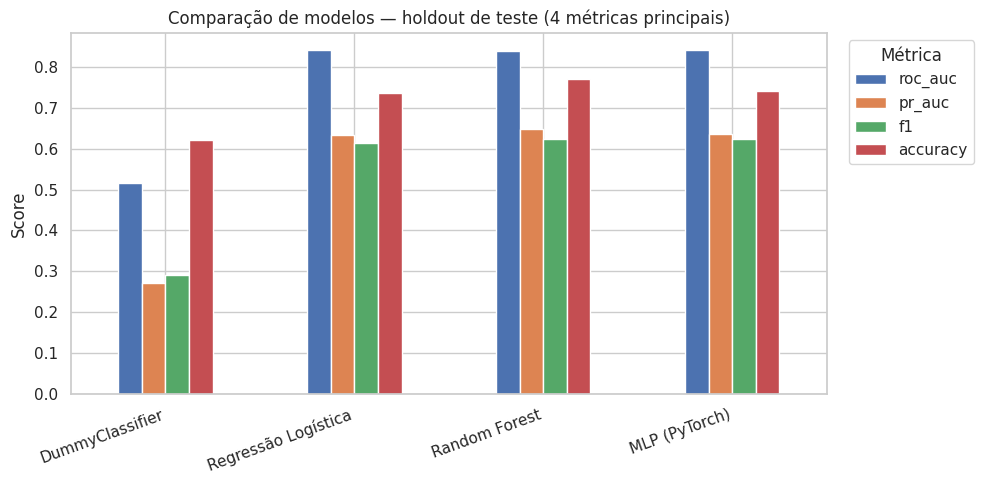

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df[["roc_auc", "pr_auc", "f1", "accuracy"]].plot(kind="bar", ax=ax)
ax.set_title("Comparação de modelos — holdout de teste (4 métricas principais)")
ax.set_ylabel("Score")
ax.set_xticklabels(comparison_df.index, rotation=20, ha="right")
ax.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Leitura dos resultados:** os quatro modelos "reais" (Regressão Logística,
Random Forest e MLP) devem performar de forma consistente entre si — todos
claramente acima do `DummyClassifier` — o que é esperado para este dataset:
o sinal preditivo é forte e robusto a diferentes famílias de algoritmo. A
MLP não necessariamente supera os baselines lineares/árvore por uma margem
grande neste volume de dados (~7k registros) — esse é um achado relevante
por si só: nem sempre a maior complexidade do modelo se traduz em ganho
proporcional, especialmente em datasets tabulares de porte moderado.


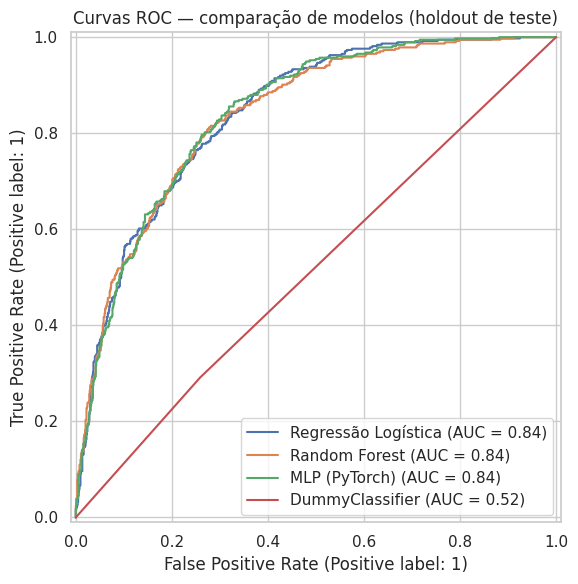

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [
    ("Regressão Logística", logreg_test_proba),
    ("Random Forest", rf_test_proba),
    ("MLP (PyTorch)", mlp_test_proba),
    ("DummyClassifier", dummy_test_proba),
]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)

ax.set_title("Curvas ROC — comparação de modelos (holdout de teste)")
plt.tight_layout()
plt.show()


## 8. Análise de trade-off de custo (Falso Positivo vs. Falso Negativo)

Aplicamos o framework de custo de negócio definido no ML Canvas
(`docs/ml_canvas.md`): cada decisão do modelo tem um custo ou ganho associado
à receita do cliente, permitindo comparar modelos por uma métrica de negócio,
não apenas estatística.

- **Falso Negativo (FN)**: perde a receita anualizada do cliente que cancelou
  sem ser identificado (`12 × MonthlyCharges`).
- **Falso Positivo (FP)**: custo fixo de uma campanha de retenção desnecessária
  (assumido em R$ 50,00 por contato).
- **Verdadeiro Positivo (TP)**: ganho líquido = receita anualizada preservada
  menos o custo da campanha que viabilizou a retenção.


In [13]:
monthly_charges_test = X_test["MonthlyCharges"]

cost_results = {
    "DummyClassifier": compute_business_cost(y_test.to_numpy(), dummy_test_pred, monthly_charges_test),
    "Regressão Logística": compute_business_cost(y_test.to_numpy(), logreg_test_pred, monthly_charges_test),
    "Random Forest": compute_business_cost(y_test.to_numpy(), rf_test_pred, monthly_charges_test),
    "MLP (PyTorch)": compute_business_cost(y_test.to_numpy(), mlp_test_pred, monthly_charges_test),
}

cost_table = cost_summary_table(cost_results)
cost_table


,n_tp,n_fp,n_fn,n_tn,cost_fn,cost_fp,gain_tp,net_cost
modelo,,,,,,,,
DummyClassifier,109,268,265,767,230401.2,13400.0,90727.6,153073.6
Regressão Logística,293,288,81,747,57599.4,14400.0,254329.4,-182330.0
Random Forest,267,214,107,821,86045.4,10700.0,227183.4,-130438.0
MLP (PyTorch),300,289,74,746,52091.4,14450.0,259487.4,-192946.0


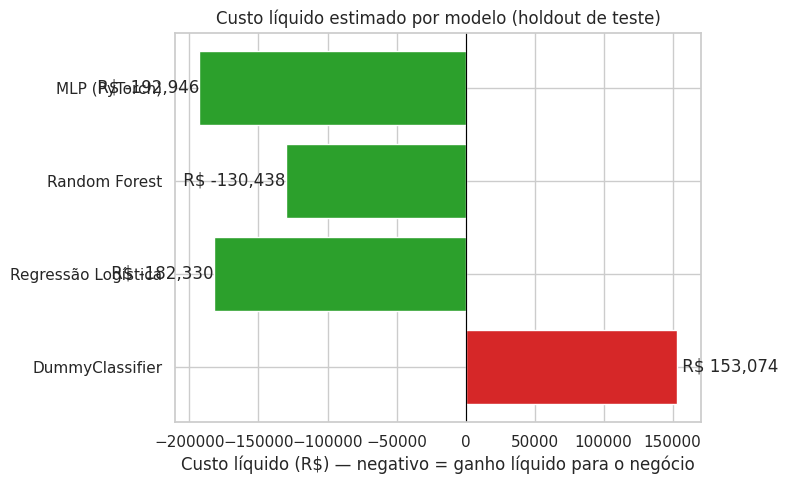

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if v > 0 else "#2ca02c" for v in cost_table["net_cost"]]
ax.barh(cost_table.index, cost_table["net_cost"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Custo líquido (R$) — negativo = ganho líquido para o negócio")
ax.set_title("Custo líquido estimado por modelo (holdout de teste)")
for i, v in enumerate(cost_table["net_cost"]):
    ax.text(v, i, f" R$ {v:,.0f}", va="center", ha="left" if v > 0 else "right")
plt.tight_layout()
plt.show()


**Leitura de negócio:** modelos com `net_cost` mais negativo geram mais valor
líquido para a operação (mais clientes de alto valor retidos a tempo, líquido
do custo das campanhas), considerando o framework de custo assumido. O
`DummyClassifier`, por construção, tende a ter o peor (ou próximo de zero)
resultado de negócio, pois não direciona campanhas de forma eficaz — reforça
visualmente por que a acurácia bruta seria uma métrica perigosa de se otimizar
isoladamente neste problema.

**Limitação importante:** os valores de `campaign_cost` (R$ 50) e o horizonte
de receita (12 meses) são estimativas parametrizáveis definidas no ML Canvas,
não dados reais de custo operacional da operadora — o framework deve ser
recalibrado com dados reais de custo de campanha antes de qualquer decisão de
negócio real.


In [15]:
# Sensibilidade: como o ranking de modelos se comporta sob diferentes custos de campanha?
campaign_costs_to_test = [10, 50, 100, 200]
sensitivity_rows = []

for cost in campaign_costs_to_test:
    for name, pred in [
        ("Regressão Logística", logreg_test_pred),
        ("Random Forest", rf_test_pred),
        ("MLP (PyTorch)", mlp_test_pred),
    ]:
        result = compute_business_cost(y_test.to_numpy(), pred, monthly_charges_test, campaign_cost=cost)
        sensitivity_rows.append({"campaign_cost": cost, "modelo": name, "net_cost": result["net_cost"]})

sensitivity_df = pd.DataFrame(sensitivity_rows).pivot(index="campaign_cost", columns="modelo", values="net_cost")
sensitivity_df.round(0)


modelo,MLP (PyTorch),Random Forest,Regressão Logística
campaign_cost,,,
10,-216506.0,-149678.0,-205570.0
50,-192946.0,-130438.0,-182330.0
100,-163496.0,-106388.0,-153280.0
200,-104596.0,-58288.0,-95180.0


**Análise de sensibilidade:** repetimos o cálculo de custo líquido variando o
custo assumido por campanha de retenção (de R$ 10 a R$ 200). Isso mostra o
quão sensível é a conclusão de negócio à premissa de custo — se o ranking
entre modelos muda drasticamente com o custo da campanha, isso é um sinal de
que a calibração precisa do custo real é crítica antes de decidir qual
modelo colocar em produção.


## 9. Registro de todos os experimentos no MLflow

Registramos os baselines (Dummy, Regressão Logística, Random Forest) e a MLP,
incluindo parâmetros de arquitetura/treinamento, métricas no holdout de teste
e métricas de custo de negócio.


In [16]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

dataset_version = "telco-customer-churn-ibm-v1"


def log_model_run(run_name, test_metrics, cost_result, extra_params=None, sklearn_pipeline=None, torch_model=None, torch_input_example=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("seed", SEED)
        mlflow.log_param("dataset_version", dataset_version)
        mlflow.log_param("n_train_samples", X_train.shape[0])
        mlflow.log_param("n_test_samples", X_test.shape[0])
        mlflow.log_param("evaluation", "holdout_test_set")
        if extra_params:
            mlflow.log_params(extra_params)

        for metric, value in test_metrics.items():
            mlflow.log_metric(f"test_{metric}", value)

        for key in ["n_tp", "n_fp", "n_fn", "n_tn", "cost_fn", "cost_fp", "gain_tp", "net_cost"]:
            mlflow.log_metric(f"business_{key}", cost_result[key])

        if sklearn_pipeline is not None:
            mlflow.sklearn.log_model(sklearn_pipeline, name="model")
        if torch_model is not None:
            # serialization_format="pickle" evita a exigência do formato 'pt2'
            # (traced-graph), que precisaria de um TensorSpec mais elaborado.
            mlflow.pytorch.log_model(
                torch_model,
                name="model",
                input_example=torch_input_example,
                serialization_format="pickle",
            )

        print(f"Run '{run_name}' registrada no MLflow.")


log_model_run(
    "etapa2_dummy_classifier",
    dummy_test_metrics,
    cost_results["DummyClassifier"],
    extra_params={"strategy": "stratified"},
    sklearn_pipeline=dummy_pipeline,
)

log_model_run(
    "etapa2_logistic_regression",
    logreg_test_metrics,
    cost_results["Regressão Logística"],
    extra_params={"class_weight": "balanced", "max_iter": 1000},
    sklearn_pipeline=logreg_pipeline,
)

log_model_run(
    "etapa2_random_forest",
    rf_test_metrics,
    cost_results["Random Forest"],
    extra_params={"n_estimators": 200, "max_depth": 10, "class_weight": "balanced"},
    sklearn_pipeline=rf_pipeline,
)

log_model_run(
    "etapa2_mlp_pytorch",
    mlp_test_metrics,
    cost_results["MLP (PyTorch)"],
    extra_params={
        "hidden_sizes": "(64, 32)",
        "dropout": 0.3,
        "batch_size": 64,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "patience": 10,
        "n_epochs_trained": train_result["n_epochs_trained"],
        "pos_weight": round(float(pos_weight), 4),
    },
    torch_model=mlp_model,
    torch_input_example=X_test_proc[:5].astype(np.float32),
)


2026/06/27 17:45:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/27 17:45:10 INFO mlflow.store.db.utils: Updating database tables


2026/06/27 17:45:10 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


Run 'etapa2_dummy_classifier' registrada no MLflow.


Run 'etapa2_logistic_regression' registrada no MLflow.


2026/06/27 17:45:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Run 'etapa2_random_forest' registrada no MLflow.


Run 'etapa2_mlp_pytorch' registrada no MLflow.


In [17]:
print(f"Experimentos registrados em: {MLFLOW_TRACKING_URI}")
print("Para visualizar: execute `mlflow ui --backend-store-uri", MLFLOW_TRACKING_URI, "--port 5001` na raiz do projeto.")


Experimentos registrados em: sqlite:////home/claude/FIAP_MLE10_TC1/mlflow.db
Para visualizar: execute `mlflow ui --backend-store-uri sqlite:////home/claude/FIAP_MLE10_TC1/mlflow.db --port 5001` na raiz do projeto.


## 10. Resumo da Etapa 2 e próximos passos

**Resumo dos achados:**

1. A MLP (PyTorch) foi treinada com sucesso, com early stopping interrompendo
   o treino antes do número máximo de épocas, evitando overfitting.
2. Um baseline de árvore (Random Forest) foi adicionado, complementando o
   baseline linear da Etapa 1 — conforme exigido pelo desafio.
3. Todos os modelos (Dummy, Regressão Logística, Random Forest, MLP) foram
   comparados no mesmo holdout de teste, usando 6 métricas (AUC-ROC, PR-AUC,
   F1, precisão, recall, acurácia) — acima do mínimo de 4 exigido.
4. O framework de custo de negócio (FP vs. FN) foi aplicado a todos os
   modelos, com análise de sensibilidade ao custo assumido de campanha.
5. Todos os experimentos foram registrados no MLflow, incluindo os modelos
   como artefatos (sklearn pipelines e o modelo PyTorch).

**Decisão de avanço:** considerando métricas técnicas e de negócio
combinadas, o modelo (ou modelos) com melhor relação custo-benefício deve
seguir como candidato à produção na Etapa 3 — a escolha final entre
Regressão Logística, Random Forest e MLP deve equilibrar performance,
interpretabilidade e custo computacional de inferência (relevante para a
API da Etapa 3).

**Próximos passos (Etapa 3):** refatoração do código em módulos (`src/`,
parcialmente já iniciado nesta etapa), pipeline reprodutível, testes
automatizados (pytest, pandera), API FastAPI (`/predict`, `/health`) e
logging estruturado.
